In [96]:
import sys

sys.path.append('../')

import pandas as pd
import Uncertainpy.src.uncertainpy.gradual as grad
from mlp_to_qbaf_converter.argument_attribution_explanation import AAE
from mlp_to_qbaf_converter.relation_attribution_explanation import RAE
from mlp_to_qbaf_converter.counterfactual_contestability_explanation import CounterfactualContestabilityExplanation
from mlp_to_qbaf_converter.utils import plot_qbaf, forward_pass, logistic
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from mlp_to_qbaf_converter.mlp_to_qbaf import MLPToQBAF
from sparx.sparx import LocalSpArX
from graphviz import Digraph
import random
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

cols = ["sepal_length", "sepal_width", "petal_length", "petal_width", "class"]
iris = pd.read_csv("../../data/iris.data", names=cols)
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [97]:
label_encoder = LabelEncoder()

iris["class"] = label_encoder.fit_transform(iris["class"])

iris.head()

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [98]:
X = iris.drop(columns="class").to_numpy()
y = iris["class"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=2024,
)

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)

# For AAEs
h = 1e-8
X_test = np.clip(scaler.transform(X_test), h, 1 - h) # Clip to avoid log errors in gradient computation later

y_train = y_train.reshape(-1)
y_test = y_test.reshape(-1)

# Logistic activation function to follow paper

classifier = MLPClassifier(
    activation="logistic",
    hidden_layer_sizes=(100, 100),
    max_iter=10000,
    random_state=2024,
    solver='lbfgs',
)
classifier.fit(X_train, y_train);

In [99]:
example_num = 17
example = X_test[example_num]

weights = classifier.coefs_
biases = classifier.intercepts_

activations = forward_pass(example, weights, biases, logistic)

dot = Digraph()
dot.attr(rankdir="LR")
dot.attr(overlap="false")  # avoid node overlaps
dot.attr(splines="true")  # use curved edges
dot.attr(margin="0")  # reduce page margin
dot.attr(pad="0")  # padding around graph
dot.attr(nodesep="0.2")
dot.attr(ranksep="0.2")

dot.attr(
    "node",
    fontsize="12",
    width="0",
    height="0",
    margin="0.01,0.01",  # very tight node margins
    style="filled",
    fillcolor="lightgrey",
)

input_features = ["Sepal Length", "Sepal Width", "Petal Length", "Petal Width"]
for i, feature in enumerate(input_features):
    dot.node(f"input_{i}", label=f"{input_features[i]}\nActivation: {activations[0][i]:.2f}")

output_names = list(label_encoder.classes_)

for i, output in enumerate(output_names):
    dot.node(f"output_{i}", label=f"{output}\nActivation: {activations[-1][i]:.2f}")

# Add hidden neurons and edges between layers
layer_sizes = [len(input_features)] + list(classifier.hidden_layer_sizes) + [len(output_names)]

# Add hidden layer neurons
for layer_idx in range(1, len(layer_sizes) - 1):
    for neuron_idx in range(layer_sizes[layer_idx]):
        dot.node(f"hidden_{layer_idx}_{neuron_idx}", label=f"Layer {layer_idx} Neuron {neuron_idx+1}\nActivation: {activations[layer_idx][neuron_idx]:.2f}")

# Add edges from input to first hidden layer
for i in range(layer_sizes[0]):
    for j in range(layer_sizes[1]):
        dot.edge(f"input_{i}", f"hidden_1_{j}")

# Add edges between hidden layers (if more than one hidden layer)
for layer_idx in range(1, len(layer_sizes) - 2):
    for i in range(layer_sizes[layer_idx]):
        for j in range(layer_sizes[layer_idx + 1]):
            dot.edge(f"hidden_{layer_idx}_{i}", f"hidden_{layer_idx+1}_{j}")

# Add edges from last hidden layer to output
for i in range(layer_sizes[-2]):
    for j in range(layer_sizes[-1]):
        dot.edge(f"hidden_{len(layer_sizes)-2}_{i}", f"output_{j}")

# dot.render("Report Figures/original_mlp_architecture", cleanup=True)
# dot

In [100]:
example_row = np.append(X_test[example_num], y_test[example_num])  
train_set = np.append(X_train, y_train.reshape(-1, 1), axis=1)
sparse_level = 90
sp = LocalSpArX(
    weights,
    biases,
    "logistic",
    sparse_level,
    example_row,
    train_set,
    np.sqrt(len(X_test)) * 0.75,
    input_features,
    output_names,
)

sp_weights, sp_biases = sp.get_sparsified_mlp()

activations = forward_pass(example, sp_weights, sp_biases, logistic)

dot = Digraph()
dot.attr(rankdir="LR")
dot.attr(overlap="false")  # avoid node overlaps
dot.attr(splines="true")  # use curved edges
dot.attr(margin="0")  # reduce page margin
dot.attr(pad="0")  # padding around graph
dot.attr(nodesep="0.2")
dot.attr(ranksep="0.2")

dot.attr(
    "node",
    fontsize="12",
    width="0",
    height="0",
    margin="0.01,0.01",  # very tight node margins
    style="filled",
    fillcolor="lightgrey",
)

input_features = ["Sepal Length", "Sepal Width", "Petal Length", "Petal Width"]
for i, feature in enumerate(input_features):
    dot.node(f"input_{i}", label=f"{input_features[i]}\nActivation: {activations[0][i]:.2f}")

output_names = list(label_encoder.classes_)

for i, output in enumerate(output_names):
    dot.node(f"output_{i}", label=f"{output}\nActivation: {activations[-1][i]:.2f}")

# Add hidden neurons and edges between layers
layer_sizes = sp.get_sparsified_shape()

# Add hidden layer neurons
for layer_idx in range(1, len(layer_sizes) - 1):
    for neuron_idx in range(layer_sizes[layer_idx]):
        dot.node(f"hidden_{layer_idx}_{neuron_idx}", label=f"Layer {layer_idx} Neuron {neuron_idx+1}\nActivation: {activations[layer_idx][neuron_idx]:.2f}")

# Add edges from input to first hidden layer
for i in range(layer_sizes[0]):
    for j in range(layer_sizes[1]):
        dot.edge(f"input_{i}", f"hidden_1_{j}")

# Add edges between hidden layers (if more than one hidden layer)
for layer_idx in range(1, len(layer_sizes) - 2):
    for i in range(layer_sizes[layer_idx]):
        for j in range(layer_sizes[layer_idx + 1]):
            dot.edge(f"hidden_{layer_idx}_{i}", f"hidden_{layer_idx+1}_{j}")

# Add edges from last hidden layer to output
for i in range(layer_sizes[-2]):
    for j in range(layer_sizes[-1]):
        dot.edge(f"hidden_{len(layer_sizes)-2}_{i}", f"output_{j}")

# dot.render("Report Figures/sparse_mlp_architecture", cleanup=True)
# dot

In [101]:
def qbaf_plotter(qbaf: grad.BAG, edge_weights: bool = True) -> Digraph:  # noqa: FBT001, FBT002
    """Create a directed graph using Graphviz.

    :param qbaf: The QBAF to plot.
    :param edge_weights: Whether to include edge weights in the graph.

    Returns:
    The directed graph object.

    """
    qbaf_graph = Digraph()
    qbaf_graph.attr(rankdir="LR")
    qbaf_graph.attr(overlap="false")  # avoid node overlaps
    qbaf_graph.attr(splines="true")  # use curved edges
    qbaf_graph.attr(margin="0")  # reduce page margin
    qbaf_graph.attr(pad="0")  # padding around graph
    qbaf_graph.attr(nodesep="0.2")
    qbaf_graph.attr(ranksep="0.2")

    qbaf_graph.attr(
        "node",
        # fontsize="12",
        # width="0",
        # height="0",
        # margin="0.01,0.01",  # very tight node margins
        style="filled",
        fillcolor="lightgrey",
    )

    # Sort arguments by layer and neuron

    for arg in qbaf.arguments.values():
        qbaf_graph.node(
            arg.name,
            label=arg.name
        )

    for attack in qbaf.attacks:
        attack_weight = round(attack.attacked.attackers[attack.attacker], 2)
        qbaf_graph.edge(
            attack.attacker.name,
            attack.attacked.name,
            style="solid",
            color="red",
            label=f"{attack_weight}" if edge_weights else "",
        )

    for support in qbaf.supports:
        support_weight = round(support.supported.supporters[support.supporter], 2)
        qbaf_graph.edge(
            support.supporter.name,
            support.supported.name,
            style="dashed",
            color="blue",
            label=f"{support_weight}" if edge_weights else "",
        )

    return qbaf_graph

neurons_per_layer = [classifier.n_features_in_,
                     *list(classifier.hidden_layer_sizes),
                     classifier.n_outputs_]


converter = MLPToQBAF(neurons_per_layer,
                      classifier.coefs_,
                      classifier.intercepts_,
                      "logistic",
                      input_features,
                      output_names,
                      example)

qbaf = converter.get_qbaf()

plot = qbaf_plotter(qbaf, edge_weights=False)

plot.render("Presentation Example/original_qbaf", cleanup=True)
# plot


'Presentation Example/original_qbaf.pdf'

In [102]:
sp_neurons_per_layer = sp.get_sparsified_shape()
sp_converter = MLPToQBAF(sp_neurons_per_layer,
                         sp_weights,
                         sp_biases,
                         "logistic",
                         input_features,
                         output_names,
                         example)
sp_qbaf = sp_converter.get_qbaf()

plot = plot_qbaf(sp_qbaf, edge_weights=False)
plot.render("Presentation Example/sparse_qbaf", cleanup=True)
# plot

'Presentation Example/sparse_qbaf.pdf'

Computing gradients: 100%|█████████████████████████████████████████| 206/206 [00:01<00:00, 144.74it/s]


206


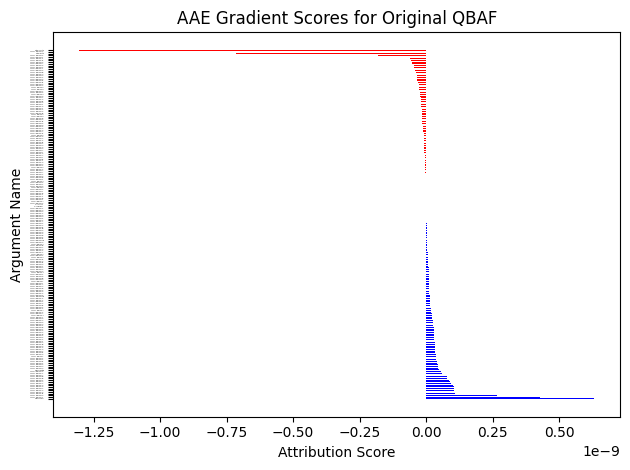

In [103]:
import matplotlib.pyplot as plt

aae = AAE(
    qbaf,
    grad.SumAggregation(),
    grad.MLPBasedInfluence(),
    output_names[0],
    1e-8,
    do_shap=False,
    do_removal=False
)

scores_full = dict(sorted(aae.get_gradients().items(), key=lambda x: x[1], reverse=True))

for name, score in scores_full.items():
    col = "red" if score < 0 else "blue"
    plt.barh(name, score, color=col, height=0.5)

plt.xlabel("Attribution Score")
plt.ylabel("Argument Name")
plt.title("AAE Gradient Scores for Original QBAF")
plt.yticks(fontsize=1)
plt.tight_layout()
print(len(scores_full))

Computing gradients: 100%|██████████████████████████████████████████| 26/26 [00:00<00:00, 5979.05it/s]


26


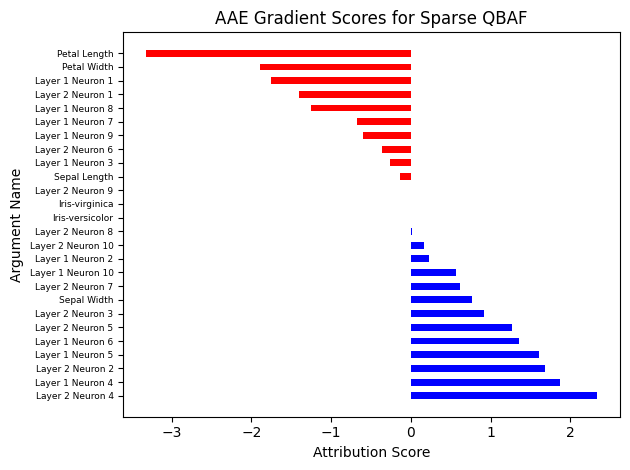

In [104]:
sp_aae = AAE(
    sp_qbaf,
    grad.SumAggregation(),
    grad.MLPBasedInfluence(),
    output_names[0],
    1e-8,
    do_shap=False,
    do_removal=False
)

scores_sparse = dict(sorted(sp_aae.get_gradients().items(), key=lambda x: x[1], reverse=True))

for name, score in scores_sparse.items():
    col = "red" if score < 0 else "blue"
    plt.barh(name, score, color=col, height=0.5)

plt.xlabel("Attribution Score")
plt.ylabel("Argument Name")
plt.title("AAE Gradient Scores for Sparse QBAF")
plt.yticks(fontsize=6.5)
plt.tight_layout()
print(len(scores_sparse))

In [105]:
# Max argument processing
max_score_arg_full = max(scores_full, key=lambda arg: abs(scores_full[arg]))

if max_score_arg_full in input_features:
    max_score_full_layer = "input"
    max_score_full_neuron = max_score_arg_full
else:
    max_score_full_split = max_score_arg_full.split(" ")
    max_score_full_layer = max_score_full_split[1]
    max_score_full_neuron = max_score_full_split[3]

max_score_arg_sparse = max(scores_sparse, key=lambda arg: abs(scores_sparse[arg]))

if max_score_arg_sparse in input_features:
    if max_score_full_layer != "input":
        print(False)
    else:
        print(max_score_full_neuron == max_score_arg_sparse)
        
else:
    max_score_sparse_split = max_score_arg_sparse.split(" ")
    max_score_sparse_layer = max_score_sparse_split[1]
    max_score_sparse_neuron = max_score_sparse_split[3]

    if max_score_full_layer != max_score_sparse_layer:
        print(False)
    else:
        containing = sp.get_containing_neurons(
            int(max_score_sparse_layer),
            int(max_score_sparse_neuron),
        )
        print(int(max_score_full_neuron) in containing)

True
